<a href="https://colab.research.google.com/github/rsakm/HealthSense-AI-Multiple-Diseases-Prediction-ML/blob/master/Codes/notebooks/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== DATA SUMMARY ===
Shape: (768, 9)

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

ross-Validation Accuracy: 0.80 (±0.06)

===CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       100
           1       0.78      0.84      0.81       100

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.80      0.80       200



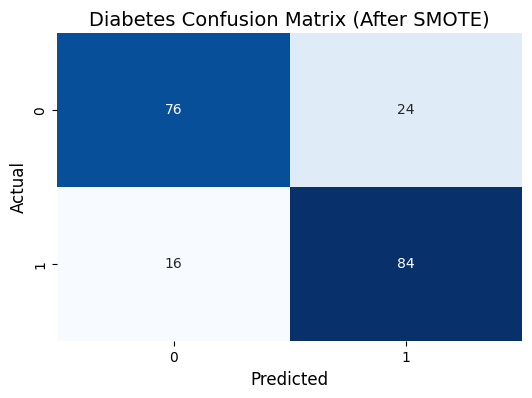

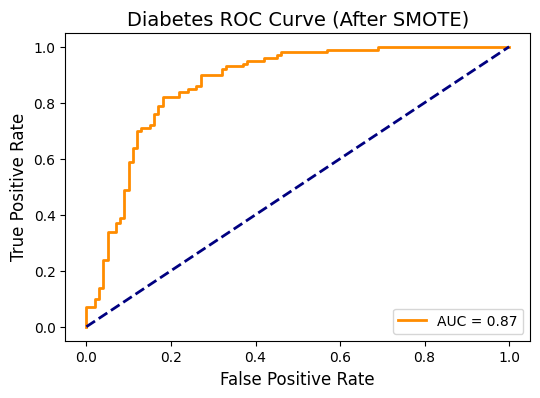


Improved model and scaler saved successfully!


In [2]:
# DIABETES PREDICTION SYSTEM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                           confusion_matrix, roc_curve, auc)
from imblearn.over_sampling import SMOTE
import pickle

# Load data
diabetes = pd.read_csv('diabetes.csv')
print("\033[1m" + "=== DATA SUMMARY ===" + "\033[0m")
print(f"Shape: {diabetes.shape}")
print("\nMissing Values:")
print(diabetes.isnull().sum())
print("\nClass Distribution:")
print(diabetes['Outcome'].value_counts())

# Handle zero values in key features
zero_fields = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diabetes[zero_fields] = diabetes[zero_fields].replace(0, np.nan)
diabetes.fillna(diabetes.mean(), inplace=True)

# Feature engineering
diabetes['BMI_Category'] = pd.cut(diabetes['BMI'],
                                bins=[0, 18.5, 25, 30, 100],
                                labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Preprocessing
X = diabetes.drop(['Outcome', 'BMI_Category'], axis=1)
y = diabetes['Outcome']

# Handle class imbalance
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_res, test_size=0.2, stratify=y_res, random_state=42
)

# Hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

model = GridSearchCV(SVC(probability=True),
                    param_grid,
                    cv=5,
                    scoring='accuracy',
                    n_jobs=-1)
model.fit(X_train, y_train)

print("\n\033[1mBest Parameters:\033[0m", model.best_params_)

# Cross-validation
cv_scores = cross_val_score(model.best_estimator_, X_scaled, y_res, cv=5, scoring='accuracy')
print(f"\n\033[Cross-Validation Accuracy: {cv_scores.mean():.2f} (±{cv_scores.std():.2f})\033[0m")

# Evaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n\033[1m===CLASSIFICATION REPORT ===\033[0m")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Diabetes Confusion Matrix (After SMOTE)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.savefig('diabetes_cm.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Diabetes ROC Curve (After SMOTE)', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right")
plt.savefig('diabetes_roc.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature Importance (for linear kernel)
if model.best_params_['kernel'] == 'linear':
    features = pd.DataFrame({
        'Feature': X.columns,
        'Importance': np.abs(model.best_estimator_.coef_[0])
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(8,4))
    sns.barplot(x='Importance', y='Feature', data=features, hue='Feature',
               palette='viridis', legend=False)
    plt.title('Diabetes Feature Importance', fontsize=14)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('')
    plt.savefig('diabetes_feature.png', dpi=300, bbox_inches='tight')
    plt.show()

# Save artifacts
pickle.dump(model.best_estimator_, open('diabetes_model.sav', 'wb'))
pickle.dump(scaler, open('diabetes_scale.sav', 'wb'))
print("\n\033[1mImproved model and scaler saved successfully!\033[0m")


